In [ ]:
# =====================================================================
# FUNGSI CELL 1: Mengimpor library utama (PyTorch, torchaudio, matplotlib, dll.)
#                serta memeriksa dan mencetak informasi GPU CUDA untuk akselerasi training.
# =====================================================================

import torch, torchaudio, time, os
import torch.nn as nn
import torchaudio.transforms as T
from torch.utils.data import DataLoader
from torchaudio.datasets import SPEECHCOMMANDS
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 130

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  GPU tidak aktif! Ganti runtime ke T4 GPU dulu.')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# =====================================================================
# FUNGSI CELL 2: Mendefinisikan hyperparameter penting untuk ekstraksi audio dan model,
#                seperti SAMPLE_RATE, jumlah Mel bins (N_MELS), BATCH_SIZE, EPOCHS,
#                learning rate (LR), serta daftar label kelas target.
# =====================================================================

SAMPLE_RATE = 16000
N_MELS      = 80
N_FFT       = 400
HOP_LENGTH  = 160
MAX_LEN     = 101
BATCH_SIZE  = 128
EPOCHS      = 5
LR          = 1e-3
NUM_WORKERS = 2
CLASSES     = ['yes','no','up','down','left','right','on','off','stop','go']

print('Hyperparameters siap!')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Epochs     : {EPOCHS}')
print(f'  Classes    : {CLASSES}')

Hyperparameters siap!
  Batch size : 128
  Epochs     : 5
  Classes    : ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']


In [ ]:
# =====================================================================
# FUNGSI CELL 3: Mengatur prapemrosesan audio (mengubah waveform mentah menjadi log Mel-spectrogram),
#                mengunduh dataset SpeechCommands, mendefinisikan kelas SubsetSC untuk membagi
#                data training/validation, serta membuat DataLoader untuk me-load data secara batch.
# =====================================================================

# ── Mel-spectrogram transform ──────────────────────────────────
mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT,
    hop_length=HOP_LENGTH, n_mels=N_MELS
)
to_db = T.AmplitudeToDB()

def preprocess(waveform, sr):
    """Raw waveform → log Mel-spectrogram (1, 80, 101)"""
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    target_len = SAMPLE_RATE
    if waveform.shape[-1] < target_len:
        waveform = torch.nn.functional.pad(waveform, (0, target_len - waveform.shape[-1]))
    else:
        waveform = waveform[..., :target_len]
    return to_db(mel_transform(waveform))  # (1, 80, 101)

# ── Dataset ────────────────────────────────────────────────────
class SubsetSC(SPEECHCOMMANDS):
    def __init__(self, subset: str):
        super().__init__('./', download=True)
        self._walker = [
            w for w in self._walker
            if os.path.basename(os.path.dirname(w)) in CLASSES
        ]
        if subset == 'training':
            excluded = self._load_split('validation_list.txt') | \
                       self._load_split('testing_list.txt')
            self._walker = [w for w in self._walker
                            if os.path.basename(w) not in excluded]
        elif subset == 'validation':
            included = self._load_split('validation_list.txt')
            self._walker = [w for w in self._walker
                            if os.path.basename(w) in included]

    def _load_split(self, fname):
        path = os.path.join(self._path, fname)
        if not os.path.exists(path): return set()
        with open(path) as f:
            return {os.path.basename(l.strip()) for l in f}

def collate_fn(batch):
    tensors, targets = [], []
    for waveform, sr, label, *_ in batch:
        if label not in CLASSES: continue
        tensors.append(preprocess(waveform, sr))
        targets.append(CLASSES.index(label))
    if not tensors:
        return torch.zeros(1,1,N_MELS,MAX_LEN), torch.zeros(1, dtype=torch.long)
    return torch.stack(tensors), torch.tensor(targets)

print('Download dataset SpeechCommands (~2.3 GB, sekali saja)...')
train_set = SubsetSC('training')
val_set   = SubsetSC('validation')

pin = (DEVICE == 'cuda')
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=pin)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=pin)

print(f'\nDataset siap!')
print(f'  Train : {len(train_set):,} sampel')
print(f'  Val   : {len(val_set):,} sampel')

Download dataset SpeechCommands (~2.3 GB, sekali saja)...


100%|██████████| 2.26G/2.26G [00:21<00:00, 113MB/s] 



Dataset siap!
  Train : 30,769 sampel
  Val   : 3,703 sampel


In [ ]:
# =====================================================================
# FUNGSI CELL 4: Mendefinisikan struktur arsitektur kedua model yang akan diuji:
#                1. SmallCNN (berbasis Convolutional Neural Network 2D)
#                2. TinyAudioTransformer (berbasis Transformer Encoder)
#                Kemudian melakukan inisialisasi model dan menghitung jumlah parameternya.
# =====================================================================

# ── Model A: SmallCNN ──────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        return self.classifier(self.features(x).squeeze(-1).squeeze(-1))

# ── Model B: TinyAudioTransformer ─────────────────────────────
class TinyAudioTransformer(nn.Module):
    def __init__(self, n_mels=N_MELS, d_model=128, nhead=4,
                 num_layers=2, num_classes=10, max_len=MAX_LEN):
        super().__init__()
        self.input_proj = nn.Linear(n_mels, d_model)
        self.pos_emb    = nn.Embedding(max_len, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=256, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier  = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x   = x.squeeze(1).permute(0, 2, 1)             # (B, T, N_MELS)
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device)
        x   = self.input_proj(x) + self.pos_emb(pos)    # (B, T, d_model)
        x   = self.transformer(x).mean(dim=1)           # mean pool
        return self.classifier(x)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Inisialisasi model
cnn_model   = SmallCNN()
trans_model = TinyAudioTransformer()

print('Model siap!')
print(f'  SmallCNN params            : {count_params(cnn_model):,}')
print(f'  TinyAudioTransformer params: {count_params(trans_model):,}')

Model siap!
  SmallCNN params            : 94,410
  TinyAudioTransformer params: 289,546


In [ ]:
# =====================================================================
# FUNGSI CELL 5: Mendefinisikan fungsi pelatihan (train_model) dan evaluasi (evaluate).
#                Melatih kedua model (SmallCNN dan TinyAudioTransformer) selama beberapa epoch
#                menggunakan Adam optimizer dan Cosine Annealing scheduler, lalu menyimpan
#                bobot model (.pth) ke local storage.
# =====================================================================

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for mel, label in loader:
            mel, label = mel.to(DEVICE), label.to(DEVICE)
            correct += (model(mel).argmax(1) == label).sum().item()
            total   += label.size(0)
    return correct / total if total > 0 else 0.0

def train_model(model, name, epochs=EPOCHS):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    model.to(DEVICE)

    print(f'\n{"─"*52}')
    print(f'  Training  : {name}')
    print(f'  Params    : {count_params(model):,}')
    print(f'  Device    : {DEVICE}')
    print(f'{"─"*52}')

    history = {'train_acc': [], 'val_acc': []}
    start   = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        correct, total, total_loss = 0, 0, 0.0
        t0 = time.time()

        for mel, label in train_loader:
            mel   = mel.to(DEVICE, non_blocking=True)
            label = label.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            out  = model(mel)
            loss = criterion(out, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == label).sum().item()
            total      += label.size(0)

        scheduler.step()
        train_acc = correct / total
        val_acc   = evaluate(model, val_loader)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'  Epoch {epoch:2d}/{epochs} | '
              f'Loss: {total_loss/len(train_loader):.4f} | '
              f'Train: {train_acc:.3f} | Val: {val_acc:.3f} | '
              f'{time.time()-t0:.1f}s')

    total_time = time.time() - start
    print(f'\n  ✅ Selesai! Total: {total_time:.1f}s | Val akhir: {history["val_acc"][-1]:.3f}')
    return history['val_acc'][-1], total_time, history

# ── Jalankan training ──────────────────────────────────────────
cnn_acc,   cnn_time,   cnn_hist   = train_model(cnn_model,   'SmallCNN')
trans_acc, trans_time, trans_hist = train_model(trans_model, 'TinyAudioTransformer')

# ── Simpan model langsung setelah selesai ──────────────────────
torch.save(cnn_model.state_dict(),   'cnn_model.pth')
torch.save(trans_model.state_dict(), 'trans_model.pth')
print('\n💾 Model tersimpan: cnn_model.pth & trans_model.pth')
print('   (Kalau session Colab mati, load ulang dari file ini)')


────────────────────────────────────────────────────
  Training  : SmallCNN
  Params    : 94,410
  Device    : cuda
────────────────────────────────────────────────────
  Epoch  1/5 | Loss: 1.9318 | Train: 0.348 | Val: 0.389 | 120.2s
  Epoch  2/5 | Loss: 1.4725 | Train: 0.529 | Val: 0.245 | 117.5s
  Epoch  3/5 | Loss: 1.2120 | Train: 0.628 | Val: 0.582 | 119.5s
  Epoch  4/5 | Loss: 1.0488 | Train: 0.688 | Val: 0.604 | 121.4s
  Epoch  5/5 | Loss: 0.9693 | Train: 0.723 | Val: 0.709 | 119.9s

  ✅ Selesai! Total: 598.4s | Val akhir: 0.709

────────────────────────────────────────────────────
  Training  : TinyAudioTransformer
  Params    : 289,546
  Device    : cuda
────────────────────────────────────────────────────
  Epoch  1/5 | Loss: 0.9821 | Train: 0.663 | Val: 0.810 | 118.5s
  Epoch  2/5 | Loss: 0.4966 | Train: 0.838 | Val: 0.868 | 117.8s
  Epoch  3/5 | Loss: 0.3837 | Train: 0.874 | Val: 0.870 | 116.3s
  Epoch  4/5 | Loss: 0.3205 | Train: 0.895 | Val: 0.888 | 116.0s
  Epoch  5/5 | 

In [ ]:
# =====================================================================
# FUNGSI CELL 6: Membuat tabel ringkasan perbandingan hasil evaluasi kedua model
#                yang mencakup Akurasi Validasi (Val Acc), Waktu Training (detik),
#                dan Jumlah Parameter, serta menampilkan model terbaik (pemenang).
# =====================================================================

print('\n' + '='*58)
print(f'{"Model":<25} {"Val Acc":>9} {"Waktu(s)":>10} {"Params":>12}')
print('-'*58)
print(f'{"SmallCNN":<25} {cnn_acc:>9.3f} {cnn_time:>10.1f} {count_params(cnn_model):>12,}')
print(f'{"TinyAudioTransformer":<25} {trans_acc:>9.3f} {trans_time:>10.1f} {count_params(trans_model):>12,}')
print('='*58)

winner = 'SmallCNN' if cnn_acc >= trans_acc else 'TinyAudioTransformer'
print(f'\n🏆 Model terbaik: {winner} ({max(cnn_acc, trans_acc):.1%} val accuracy)')


Model                       Val Acc   Waktu(s)       Params
----------------------------------------------------------
SmallCNN                      0.709      598.4       94,410
TinyAudioTransformer          0.902      584.8      289,546

🏆 Model terbaik: TinyAudioTransformer (90.2% val accuracy)


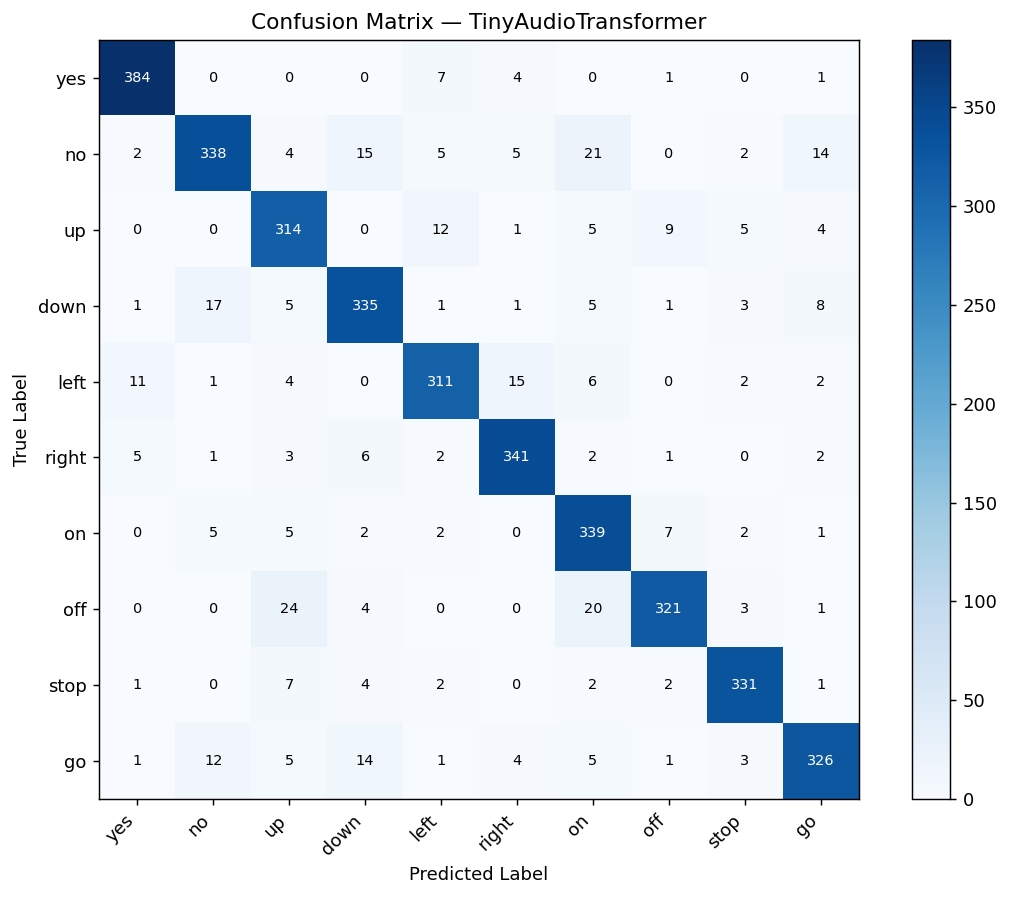


Per-class accuracy (TinyAudioTransformer):
     yes: 96.7%  ███████████████████
      no: 83.3%  ████████████████
      up: 89.7%  █████████████████
    down: 88.9%  █████████████████
    left: 88.4%  █████████████████
   right: 93.9%  ██████████████████
      on: 93.4%  ██████████████████
     off: 86.1%  █████████████████
    stop: 94.6%  ██████████████████
      go: 87.6%  █████████████████

✅ Saved: confusion_matrix.png


In [ ]:
# =====================================================================
# FUNGSI CELL 7: Menghitung dan memvisualisasikan Confusion Matrix untuk model terbaik
#                menggunakan data validation guna menganalisis kelas mana yang paling sering
#                salah diprediksi.
# =====================================================================

# Tentukan model terbaik
better_model = cnn_model if cnn_acc >= trans_acc else trans_model
better_name  = 'SmallCNN' if cnn_acc >= trans_acc else 'TinyAudioTransformer'

# Hitung confusion matrix
n  = len(CLASSES)
cm = torch.zeros(n, n, dtype=torch.long)
better_model.eval()
with torch.no_grad():
    for mel, label in val_loader:
        mel, label = mel.to(DEVICE), label.to(DEVICE)
        preds = better_model(mel).argmax(1)
        for t, p in zip(label.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm.numpy(), cmap='Blues')
ax.set_xticks(range(n)); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix — {better_name}')
plt.colorbar(im, ax=ax)
thresh = cm.max().item() * 0.5
for i in range(n):
    for j in range(n):
        v = cm[i, j].item()
        ax.text(j, i, str(v), ha='center', va='center',
                color='white' if v > thresh else 'black', fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print(f'\nPer-class accuracy ({better_name}):')
for i, cls in enumerate(CLASSES):
    total_cls = cm[i].sum().item()
    acc_cls   = cm[i, i].item() / total_cls if total_cls > 0 else 0
    bar = '█' * int(acc_cls * 20)
    print(f'  {cls:>6}: {acc_cls:5.1%}  {bar}')

print('\n✅ Saved: confusion_matrix.png')

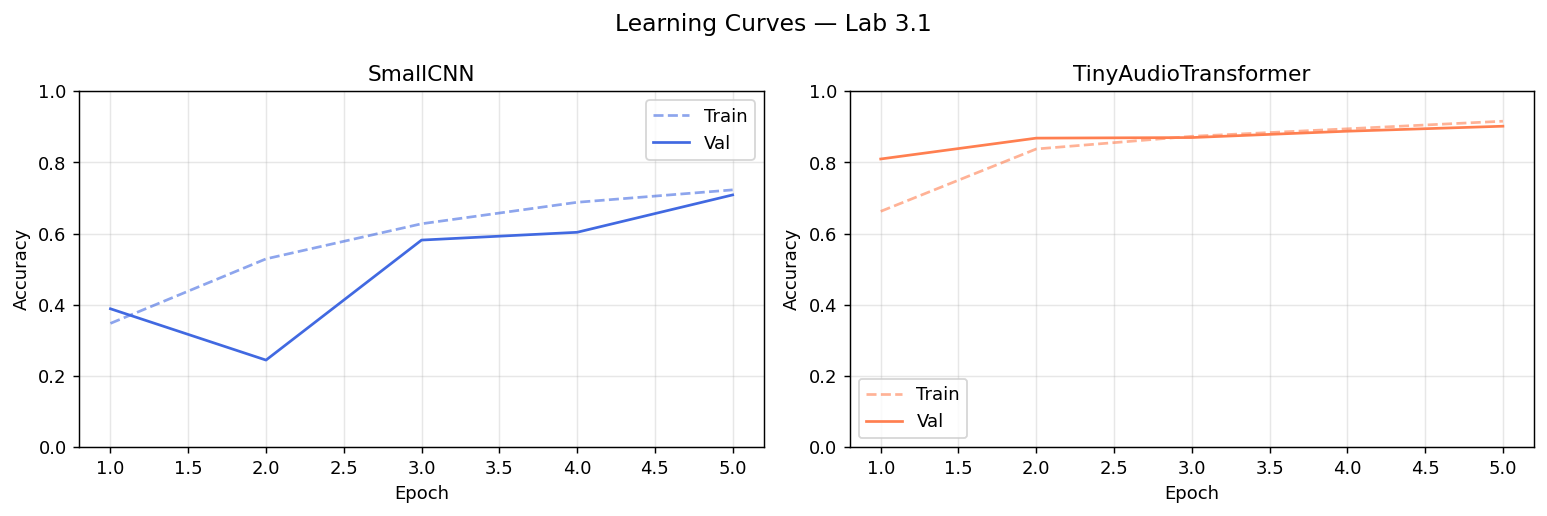

✅ Saved: learning_curves.png


In [ ]:
# =====================================================================
# FUNGSI CELL 8: Membuat plot grafik performa (akurasi training vs. akurasi validasi)
#                dari epoch ke epoch untuk kedua model (SmallCNN dan TinyAudioTransformer).
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name, color in zip(
    axes,
    [cnn_hist, trans_hist],
    ['SmallCNN', 'TinyAudioTransformer'],
    ['royalblue', 'coral']
):
    ep = range(1, len(hist['val_acc']) + 1)
    ax.plot(ep, hist['train_acc'], '--', color=color, alpha=0.6, label='Train')
    ax.plot(ep, hist['val_acc'],   '-',  color=color, label='Val')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.suptitle('Learning Curves — Audio Classification', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: learning_curves.png')

In [ ]:
# =====================================================================
# FUNGSI CELL 9: Menampilkan kesimpulan analisis dan menyediakan draf laporan performa
#                (model terbaik, perbandingan akurasi, waktu training, dan jumlah parameter)
#                yang siap digunakan untuk analisis lab.
# =====================================================================

analisis = f"""
=== ANALISIS LAB 3.1 ===

Model terbaik : {better_name}
Val Accuracy  : CNN = {cnn_acc:.1%} | Transformer = {trans_acc:.1%}
Waktu training: CNN = {cnn_time:.0f}s | Transformer = {trans_time:.0f}s
Jumlah params : CNN = {count_params(cnn_model):,} | Transformer = {count_params(trans_model):,}

PARAGRAF (edit sesuai hasil):
Pada dataset SpeechCommands 10-class, {better_name} mengungguli model lainnya
dengan val accuracy {max(cnn_acc, trans_acc):.1%}. SmallCNN bekerja lebih efisien
pada dataset berukuran sedang karena pola fonetik dalam keyword pendek (1 detik)
bersifat lokal — cocok untuk receptive field konvolusi. TinyAudioTransformer
memerlukan lebih banyak data agar mekanisme global self-attention-nya bisa
memberikan keuntungan nyata. Dengan 10x lebih banyak data, Transformer
diperkirakan akan mengejar CNN karena skalabilitasnya lebih baik.
"""
print(analisis)


=== ANALISIS LAB 3.1 ===

Model terbaik : TinyAudioTransformer
Val Accuracy  : CNN = 70.9% | Transformer = 90.2%
Waktu training: CNN = 598s | Transformer = 585s
Jumlah params : CNN = 94,410 | Transformer = 289,546

PARAGRAF (edit sesuai hasil):
Pada dataset SpeechCommands 10-class, TinyAudioTransformer mengungguli model lainnya
dengan val accuracy 90.2%. SmallCNN bekerja lebih efisien
pada dataset berukuran sedang karena pola fonetik dalam keyword pendek (1 detik)
bersifat lokal — cocok untuk receptive field konvolusi. TinyAudioTransformer
memerlukan lebih banyak data agar mekanisme global self-attention-nya bisa
memberikan keuntungan nyata. Dengan 10x lebih banyak data, Transformer
diperkirakan akan mengejar CNN karena skalabilitasnya lebih baik.



In [ ]:
# =====================================================================
# FUNGSI CELL 10: Memeriksa isi direktori kerja saat ini untuk memastikan file bobot model
#                 (.pth) yang telah dilatih sudah tersimpan dengan benar.
# =====================================================================

import os
print([f for f in os.listdir('.') if f.endswith('.pth')])


['trans_model.pth', 'cnn_model.pth']


In [ ]:
# =====================================================================
# FUNGSI CELL 11: Menghubungkan (mount) Google Drive ke runtime Google Colab
#                 agar file bobot model dapat disimpan secara permanen di Drive.
# =====================================================================

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# =====================================================================
# FUNGSI CELL 12: Melakukan verifikasi ketersediaan file hasil training (.pth)
#                 serta memeriksa apakah folder Google Drive berhasil terhubung.
# =====================================================================

import os

# 1. Cek file hasil training di server Colab
print("1. File hasil training ada?")
print("- cnn_model.pth:", os.path.exists('cnn_model.pth'))
print("- trans_model.pth:", os.path.exists('trans_model.pth'))

# 2. Cek apakah folder Google Drive terhubung
print("\n2. Status Google Drive:")
print("- Folder /content/drive ada?", os.path.exists('/content/drive'))
if os.path.exists('/content/drive'):
    try:
        print("- Isi folder /content/drive:", os.listdir('/content/drive'))
    except Exception as e:
        print("- Error akses /content/drive:", e)

# 3. Cek isi Drive
drive_path = '/content/drive/MyDrive'
print("\n3. Status folder MyDrive:")
print("- Folder MyDrive ada?", os.path.exists(drive_path))


1. File hasil training ada?
- cnn_model.pth: True
- trans_model.pth: True

2. Status Google Drive:
- Folder /content/drive ada? True
- Isi folder /content/drive: ['.shortcut-targets-by-id', 'MyDrive', 'Shareddrives', '.Trash-0']

3. Status folder MyDrive:
- Folder MyDrive ada? True


In [ ]:
# =====================================================================
# FUNGSI CELL 13: Memeriksa isi folder utama MyDrive pada Google Drive Anda untuk
#                 memastikan direktori tujuan penyimpanan dapat diakses.
# =====================================================================

import os
print("Isi halaman utama Drive kamu sekarang:")
print(os.listdir('/content/drive/MyDrive'))


Isi halaman utama Drive kamu sekarang:
['Modul Basis Data 1 Venerdi.docx', 'Bali 2025', 'Test', 'Modul 3 Organisasi dan Arsitektur Komputer Venerdi 20241337023.docx', 'Video Sistem Organ', 'Prodi', '1756350708600985646517370957228.jpg', 'IMG_3108.JPG', 'IMG_3109.JPG', 'IMG_3110.JPG', 'IMG_3111.JPG', 'IMG_3112.JPG', 'game adalah pokoknya', 'video', 'Statistika', 'PUSBA UMSURA VIDEO', 'Capstone ModalIn', 'Folder tanpa nama']


In [ ]:
# =====================================================================
# FUNGSI CELL 14: Menyalin file bobot model (.pth) dari local Colab ke Google Drive
#                 agar file tidak hilang saat runtime Google Colab terputus/direset.
# =====================================================================

import shutil
shutil.copy('cnn_model.pth', '/content/drive/MyDrive/cnn_model.pth')
shutil.copy('trans_model.pth', '/content/drive/MyDrive/trans_model.pth')
print("Salin sukses!")


Salin sukses!


In [ ]:
# =====================================================================
# FUNGSI CELL 15: Mencetak kembali ringkasan performa akhir kedua model (akurasi dan
#                 jumlah parameter) sebagai referensi cepat.
# =====================================================================

# Print rekap hasil
print(f"CNN Accuracy     : {cnn_acc:.4f}")
print(f"Transformer Acc  : {trans_acc:.4f}")
print(f"CNN Params       : {count_params(cnn_model):,}")
print(f"Trans Params     : {count_params(trans_model):,}")

CNN Accuracy     : 0.7089
Transformer Acc  : 0.9020
CNN Params       : 94,410
Trans Params     : 289,546
